# Reconnaissance d'Expressions Faciales — Deep Learning
### CNN from scratch · FER-2013 · PyTorch · GPU Colab

**Instructions :** `Runtime → Change runtime type → T4 GPU`, puis `Runtime → Run all`


## 1. Vérification du GPU

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  Pas de GPU détecté — allez dans Runtime → Change runtime type → T4 GPU")


Device : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


## 2. Installation des dépendances

In [2]:
%%capture
!pip install kaggle torchmetrics matplotlib seaborn tqdm


## 3. Téléchargement du dataset FER-2013

**Option A (recommandée) — depuis HuggingFace (aucune clé API requise) :**  
On utilise `datasets` de HuggingFace qui héberge FER-2013 directement.

**Option B — depuis Kaggle :**  
Uploader votre fichier `kaggle.json` dans la cellule suivante.


In [4]:
# ── Option A : HuggingFace (automatique) ────────────────────────────────────
!pip install datasets -q

from datasets import load_dataset
print("Téléchargement de FER-2013 depuis HuggingFace...")
hf_ds = load_dataset("Piro17/FER2013-split")
print(hf_ds)
print("Colonnes :", hf_ds["train"].column_names)


Téléchargement de FER-2013 depuis HuggingFace...


DatasetNotFoundError: Dataset 'Piro17/FER2013-split' doesn't exist on the Hub or cannot be accessed.

### Problème avec HuggingFace — On passe à l'Option B (Kaggle)

Il semblerait que le dataset `Piro17/FER2013-split` ne soit plus accessible sur HuggingFace. Nous allons donc utiliser l'option Kaggle pour télécharger les données.

Pour télécharger le dataset FER-2013 depuis Kaggle, vous devez d'abord obtenir votre clé API Kaggle (`kaggle.json`).

**Comment obtenir votre `kaggle.json` :**
1. Allez sur le site web de Kaggle et connectez-vous.
2. Cliquez sur votre profil dans le coin supérieur droit, puis sélectionnez "My Account".
3. Faites défiler jusqu'à la section "API" et cliquez sur "Create New API Token". Cela téléchargera un fichier `kaggle.json`.

Une fois que vous avez votre fichier `kaggle.json`, exécutez la cellule suivante pour l'uploader dans Colab.

In [5]:
from google.colab import files

# Téléchargez votre fichier kaggle.json
print("Veuillez uploader votre fichier kaggle.json")
files.upload()

# Créez le répertoire .kaggle et déplacez le fichier
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API key configurée.")


Veuillez uploader votre fichier kaggle.json


Saving kaggle.json to kaggle.json
Kaggle API key configurée.


Maintenant que Kaggle est configuré, nous pouvons télécharger le dataset FER-2013.

In [6]:
# Téléchargez le dataset FER-2013 depuis Kaggle
print("Téléchargement du dataset FER-2013 depuis Kaggle...")
!kaggle datasets download -d msambare/fer2013

# Décompressez le dataset
print("Décompression du dataset...")
!unzip -q fer2013.zip -d fer2013
!rm fer2013.zip

print("Dataset FER-2013 téléchargé et décompressé dans le dossier 'fer2013'.")


Téléchargement du dataset FER-2013 depuis Kaggle...
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 252MB/s]

Décompression du dataset...
Dataset FER-2013 téléchargé et décompressé dans le dossier 'fer2013'.


Le dataset est maintenant disponible localement. Cependant, le code actuel est configuré pour utiliser l'API HuggingFace. Nous devons adapter les classes `FERDataset` et `DataLoader` pour charger les images depuis le dossier décompressé, ou si le dataset est un fichier CSV, le charger à partir de là. Le dataset Kaggle 'fer2013' est généralement un fichier CSV `fer2013.csv` contenant les pixels.

### Nouvelle stratégie de chargement des données

Le dataset Kaggle `msambare/fer2013` est un ensemble d'images organisé en dossiers (`train`, `test`, `Validation`) par catégorie d'émotion, et non un fichier CSV. Nous avons donc adapté la classe `FERDataset` pour lire directement les images depuis ces dossiers, en utilisant les noms de dossiers comme labels. La cellule précédente qui tentait de charger un CSV a été remplacée par cette explication.

## 4. Imports & configuration globale

In [15]:
import os, random, time, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchmetrics
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

# ── Reproductibilité
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── Hyperparamètres
CFG = dict(
    img_size   = 48,
    batch_size = 128,
    epochs     = 60,
    lr         = 1e-3,
    weight_decay = 1e-4,
    label_smoothing = 0.1,
    dropout    = 0.5,
    num_classes = 7,
    num_workers = 2,
)

EMOTIONS = ["Colère", "Dégoût", "Peur", "Joie", "Tristesse", "Surprise", "Neutre"]
print("Config :", json.dumps(CFG, indent=2))
print("Device :", device)


Config : {
  "img_size": 48,
  "batch_size": 128,
  "epochs": 60,
  "lr": 0.001,
  "weight_decay": 0.0001,
  "label_smoothing": 0.1,
  "dropout": 0.5,
  "num_classes": 7,
  "num_workers": 2
}
Device : cuda


## 5. Dataset PyTorch & augmentation

In [20]:
import os, random
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class FERDataset(Dataset):
    """Dataset PyTorch pour le dataset FER-2013 depuis les fichiers locaux."""

    TRAIN_TF = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((CFG["img_size"], CFG["img_size"])),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(12),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    VAL_TF = transforms.Compose([
        transforms.Grayscale(),
        transforms.Resize((CFG["img_size"], CFG["img_size"])),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ])

    def __init__(self, root_dir, split, is_train: bool = True):
        self.root_dir = root_dir
        self.split = split
        self.is_train = is_train
        self.tf = self.TRAIN_TF if is_train else self.VAL_TF
        self.image_paths, self.labels = self._load_data()

    def _load_data(self):
        image_paths = []
        labels = []
        # Mapping standard English emotion folder names to EMOTIONS list indices
        english_to_french_emotions = {
            "angry": "Colère",
            "disgust": "Dégoût",
            "fear": "Peur",
            "happy": "Joie",
            "sad": "Tristesse",
            "surprise": "Surprise",
            "neutral": "Neutre"
        }
        french_emotion_to_label_idx = {name: idx for idx, name in enumerate(EMOTIONS)}

        # Try multiple common names for the split directory
        possible_split_names = [self.split]
        if self.split == 'validation':
            possible_split_names.extend(['Validation', 'val'])
        elif self.split == 'train':
            possible_split_names.extend(['Train'])
        elif self.split == 'test':
            possible_split_names.extend(['Test'])

        found_split_dir = None
        for name_attempt in possible_split_names:
            candidate_dir = os.path.join(self.root_dir, name_attempt)
            if os.path.exists(candidate_dir):
                found_split_dir = candidate_dir
                break

        if found_split_dir is None:
            # If no explicit split directory is found for validation, it's fine.
            # We assume it will be handled by splitting the training set.
            if self.split == 'validation':
                return [], [] # Return empty lists if validation split not found and will be created from train
            else:
                raise FileNotFoundError(f"Split directory not found for '{self.split}' in {self.root_dir}. Tried: {', '.join([os.path.join(self.root_dir, n) for n in possible_split_names])}")

        split_dir = found_split_dir

        for emotion_folder_en in os.listdir(split_dir):
            if emotion_folder_en.lower() not in english_to_french_emotions:
                continue # Skip unexpected folders

            french_emotion_name = english_to_french_emotions[emotion_folder_en.lower()]
            if french_emotion_name not in french_emotion_to_label_idx:
                continue # Skip if no mapping in EMOTIONS

            label = french_emotion_to_label_idx[french_emotion_name]
            emotion_path = os.path.join(split_dir, emotion_folder_en)
            if os.path.isdir(emotion_path):
                for img_name in os.listdir(emotion_path):
                    if img_name.endswith(('.jpg', '.png', '.jpeg')):
                        image_paths.append(os.path.join(emotion_path, img_name))
                        labels.append(label)
        return image_paths, labels

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert('L') # Load as grayscale PIL image
        img = self.tf(img)
        return img, label

dataset_root = "./fer2013" # The folder where the unzipped dataset is located, adjusted for nested folder

# Load the full training dataset
full_train_ds = FERDataset(dataset_root, "train", is_train=True)

# Split the training dataset into training and validation sets
train_size = int(0.8 * len(full_train_ds))
val_size = len(full_train_ds) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_train_ds, [train_size, val_size])


test_ds  = FERDataset(dataset_root, "test",  is_train=False)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"],
                          shuffle=True,  num_workers=CFG["num_workers"],
                          pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"],
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                          shuffle=False, num_workers=CFG["num_workers"],
                          pin_memory=True)

print(f"Train : {len(train_ds):,} images")
print(f"Val   : {len(val_ds):,} images")
print(f"Test  : {len(test_ds):,} images")

Train : 22,967 images
Val   : 5,742 images
Test  : 7,178 images


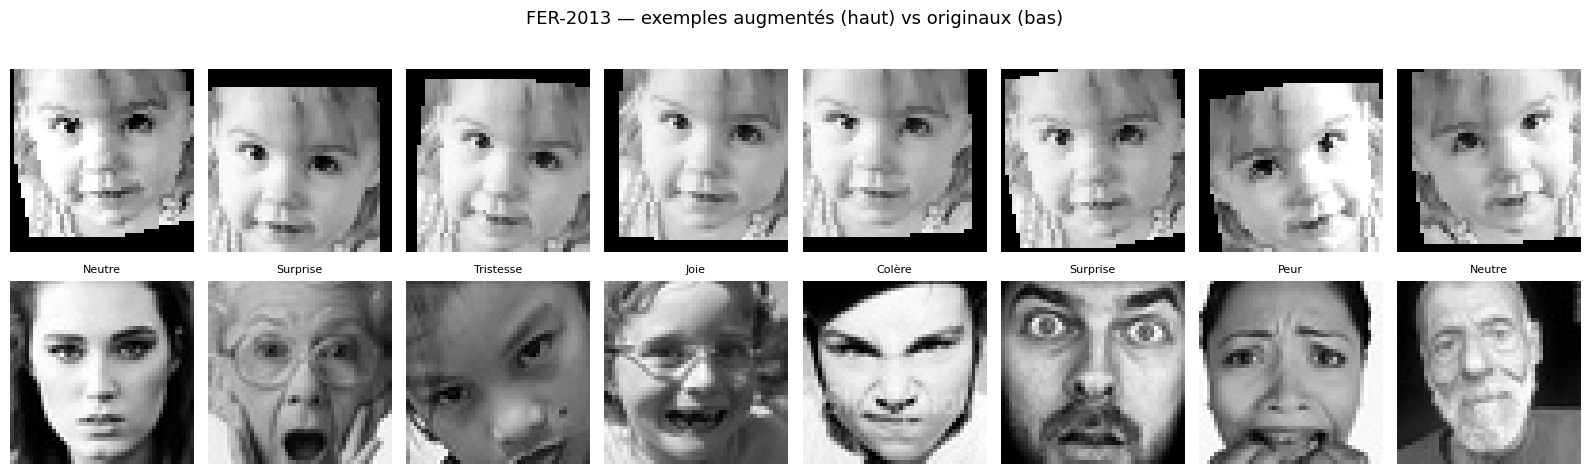

In [23]:
import matplotlib.pyplot as plt
import random # Added import for random
from PIL import Image # Added import for Image

# Visualiser quelques exemples avec et sans augmentation
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("FER-2013 — exemples augmentés (haut) vs originaux (bas)", fontsize=13)

# Get a random image path from the training set to use as the base for augmentation
idx_raw_img = random.randint(0, len(train_ds) - 1)
# Fix: Access image_paths through the original dataset and map the index
raw_img_path = train_ds.dataset.image_paths[train_ds.indices[idx_raw_img]]
raw_img_pil = Image.open(raw_img_path).convert('L') # Load as grayscale PIL image

for i in range(8):
    aug = FERDataset.TRAIN_TF(raw_img_pil) # Apply TRAIN_TF to the PIL image
    axes[0, i].imshow(aug.squeeze().numpy() * 0.5 + 0.5, cmap="gray")
    axes[0, i].axis("off")

for i in range(8):
    # Get a random image from the training dataset for original view
    idx  = random.randint(0, len(train_ds) - 1)
    # Fix: Access image_paths and labels through the original dataset and map the index
    img_path_orig = train_ds.dataset.image_paths[train_ds.indices[idx]]
    label_orig = train_ds.dataset.labels[train_ds.indices[idx]]
    img_pil_orig = Image.open(img_path_orig).convert('L')

    orig = FERDataset.VAL_TF(img_pil_orig) # Apply VAL_TF to show a standardized 'original'
    axes[1, i].imshow(orig.squeeze().numpy() * 0.5 + 0.5, cmap="gray")
    axes[1, i].set_title(EMOTIONS[label_orig], fontsize=8)
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 6. Architecture CNN (FERNet)

In [24]:
class ConvBlock(nn.Module):
    """Conv2D → BatchNorm → ReLU → MaxPool → Dropout2d"""
    def __init__(self, in_ch, out_ch, pool=True, drop=0.25):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool: layers.append(nn.MaxPool2d(2))
        layers.append(nn.Dropout2d(drop))
        self.block = nn.Sequential(*layers)

    def forward(self, x): return self.block(x)


class FERNet(nn.Module):
    """
    CNN 3-blocs pour FER-2013 (48×48 → 7 classes).
    Paramètres : ~1.1 M
    """
    def __init__(self, num_classes=7, dropout=0.5):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(1,  32, pool=True,  drop=0.25),  # 48→24
            ConvBlock(32, 64, pool=True,  drop=0.25),  # 24→12
            ConvBlock(64, 128, pool=True, drop=0.25),  # 12→6
        )
        self.pool = nn.AdaptiveAvgPool2d(1)             # 6→1
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)


model = FERNet(num_classes=CFG["num_classes"], dropout=CFG["dropout"]).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres totaux     : {total_params:,}")
print(f"Paramètres entraînables : {train_params:,}")
print(model)


Paramètres totaux     : 321,703
Paramètres entraînables : 321,703
FERNet(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout2d(p=0.25, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3)

## 7. Entraînement complet

In [25]:
# ── Optimiseur, scheduler, loss
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CFG["lr"],
    steps_per_epoch=len(train_loader),
    epochs=CFG["epochs"],
    pct_start=0.1,
)
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

# ── Métriques (torchmetrics)
acc_metric = torchmetrics.Accuracy(
    task="multiclass", num_classes=CFG["num_classes"]
).to(device)

# ── Historique
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
CKPT_PATH = "fer_best.pt"


def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        acc_metric.update(logits.argmax(1), labels)

    return total_loss / len(loader), acc_metric.compute().item()


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits     = model(imgs)
        total_loss += criterion(logits, labels).item()
        acc_metric.update(logits.argmax(1), labels)

    return total_loss / len(loader), acc_metric.compute().item()


# ── Boucle principale
print(f"{'Époque':>6}  {'LR':>9}  {'L-train':>8}  {'Acc-train':>10}  {'L-val':>7}  {'Acc-val':>8}  {'Status':>7}")
print("─" * 72)

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    lr_now = scheduler.get_last_lr()[0]

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)
    history["lr"].append(lr_now)

    status = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "val_acc": vl_acc, "cfg": CFG}, CKPT_PATH)
        status = "★ saved"

    elapsed = time.time() - t0
    print(f"{epoch:>6}  {lr_now:>9.2e}  {tr_loss:>8.4f}  {tr_acc:>9.1%}  "
          f"{vl_loss:>7.4f}  {vl_acc:>7.1%}  {status}")

print(f"\n✅ Meilleure val accuracy : {best_val_acc:.1%}")


Époque         LR   L-train   Acc-train    L-val   Acc-val   Status
────────────────────────────────────────────────────────────────────────
     1   1.04e-04    2.1336      18.9%   1.8392    24.7%  ★ saved
     2   2.80e-04    1.9078      22.2%   1.8373    24.7%  ★ saved
     3   5.21e-04    1.8528      24.0%   1.8338    24.6%  
     4   7.61e-04    1.8434      24.9%   1.8333    25.0%  ★ saved
     5   9.36e-04    1.8339      25.2%   1.8214    25.2%  ★ saved
     6   1.00e-03    1.8278      25.9%   1.8146    27.3%  ★ saved
     7   9.99e-04    1.8173      26.1%   1.7917    26.9%  
     8   9.97e-04    1.7993      27.7%   1.7587    30.2%  ★ saved
     9   9.92e-04    1.7696      29.7%   1.7177    31.9%  ★ saved
    10   9.86e-04    1.7450      31.5%   1.7009    32.8%  ★ saved
    11   9.79e-04    1.7121      33.6%   1.6444    38.8%  ★ saved
    12   9.70e-04    1.6626      37.3%   1.6394    39.9%  ★ saved
    13   9.59e-04    1.6227      39.7%   1.5576    44.2%  ★ saved
    14   9.47e-

## 8. Courbes d'entraînement

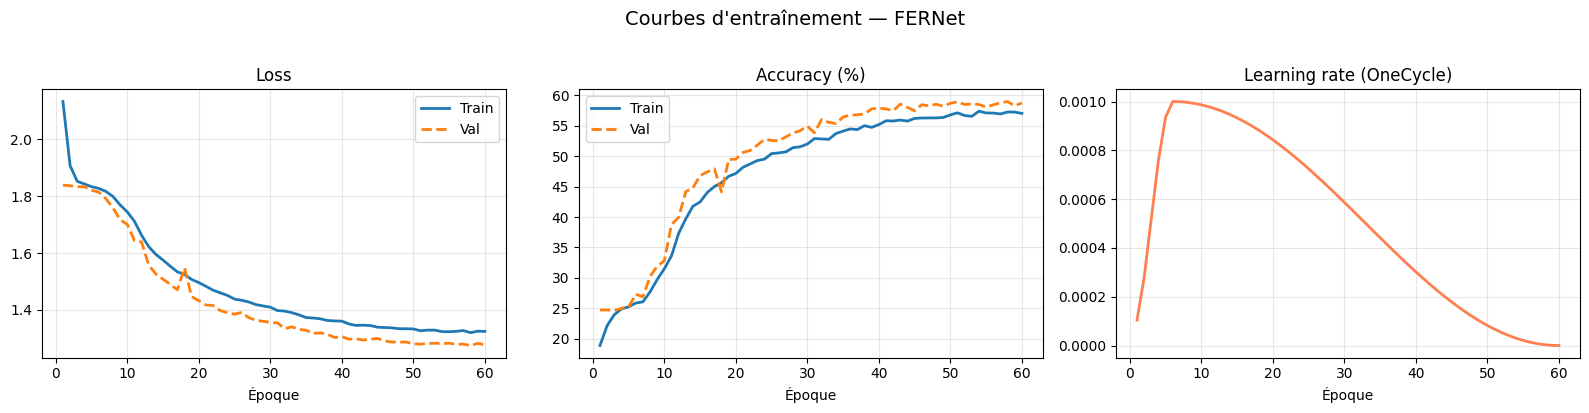

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_x, history["train_loss"], label="Train", lw=2)
axes[0].plot(epochs_x, history["val_loss"],   label="Val",   lw=2, linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Époque")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, [a*100 for a in history["train_acc"]], label="Train", lw=2)
axes[1].plot(epochs_x, [a*100 for a in history["val_acc"]],   label="Val",   lw=2, linestyle="--")
axes[1].set_title("Accuracy (%)"); axes[1].set_xlabel("Époque")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_x, history["lr"], color="coral", lw=2)
axes[2].set_title("Learning rate (OneCycle)"); axes[2].set_xlabel("Époque")
axes[2].grid(alpha=0.3)

plt.suptitle("Courbes d'entraînement — FERNet", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 9. Évaluation finale sur le test set

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

# Charger le meilleur checkpoint
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model"])
print(f"Meilleur modèle chargé — époque {ckpt['epoch']}, val acc {ckpt['val_acc']:.1%}")

# Collecte des prédictions
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Test"):
        imgs = imgs.to(device, non_blocking=True)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Rapport textuel
print("\n" + classification_report(all_labels, all_preds, target_names=EMOTIONS))


Meilleur modèle chargé — époque 58, val acc 59.0%


Test:   0%|          | 0/57 [00:00<?, ?it/s]


              precision    recall  f1-score   support

      Colère       0.51      0.45      0.48       958
      Dégoût       0.00      0.00      0.00       111
        Peur       0.40      0.16      0.23      1024
        Joie       0.79      0.88      0.83      1774
   Tristesse       0.45      0.53      0.49      1247
    Surprise       0.69      0.79      0.74       831
      Neutre       0.52      0.66      0.58      1233

    accuracy                           0.59      7178
   macro avg       0.48      0.49      0.48      7178
weighted avg       0.57      0.59      0.57      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


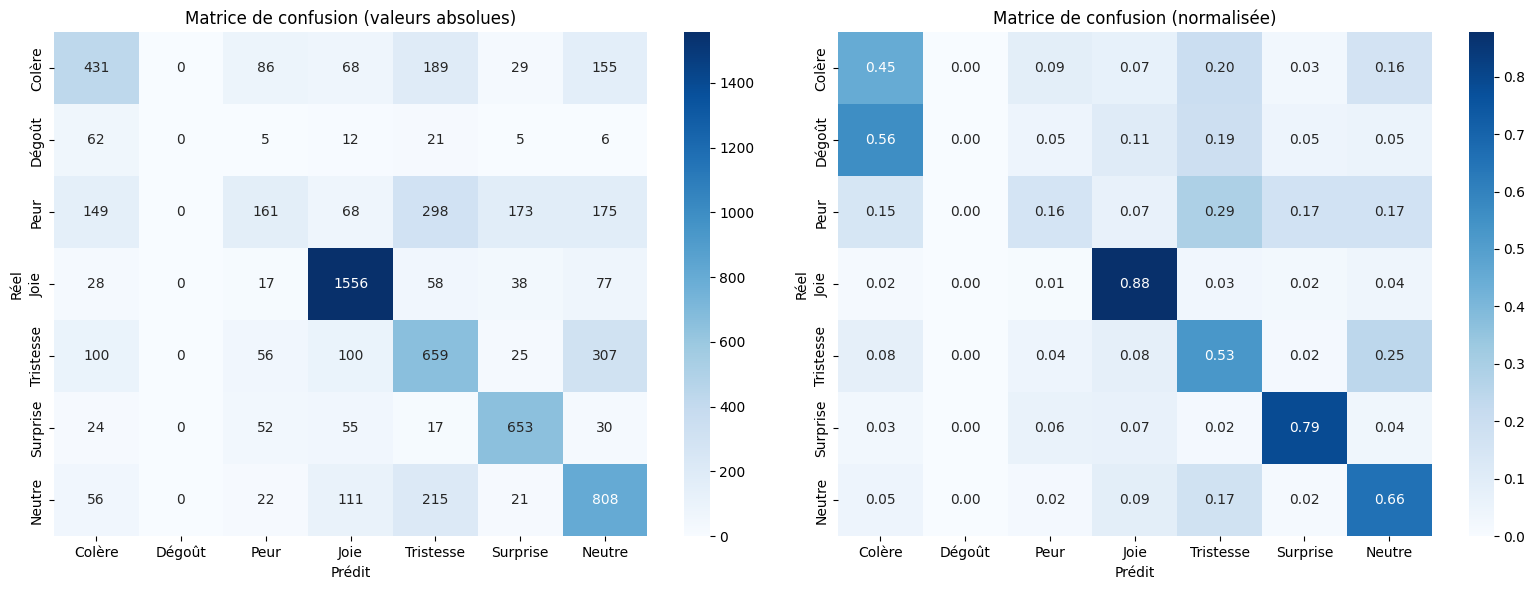

Accuracy globale sur le test set : 59.5%


In [28]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolue
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[0])
axes[0].set_title("Matrice de confusion (valeurs absolues)")
axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")

# Normalisée
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=axes[1])
axes[1].set_title("Matrice de confusion (normalisée)")
axes[1].set_xlabel("Prédit"); axes[1].set_ylabel("Réel")

plt.tight_layout()
plt.show()
global_acc = (all_preds == all_labels).mean()
print(f"Accuracy globale sur le test set : {global_acc:.1%}")


## 10. Visualisation des prédictions

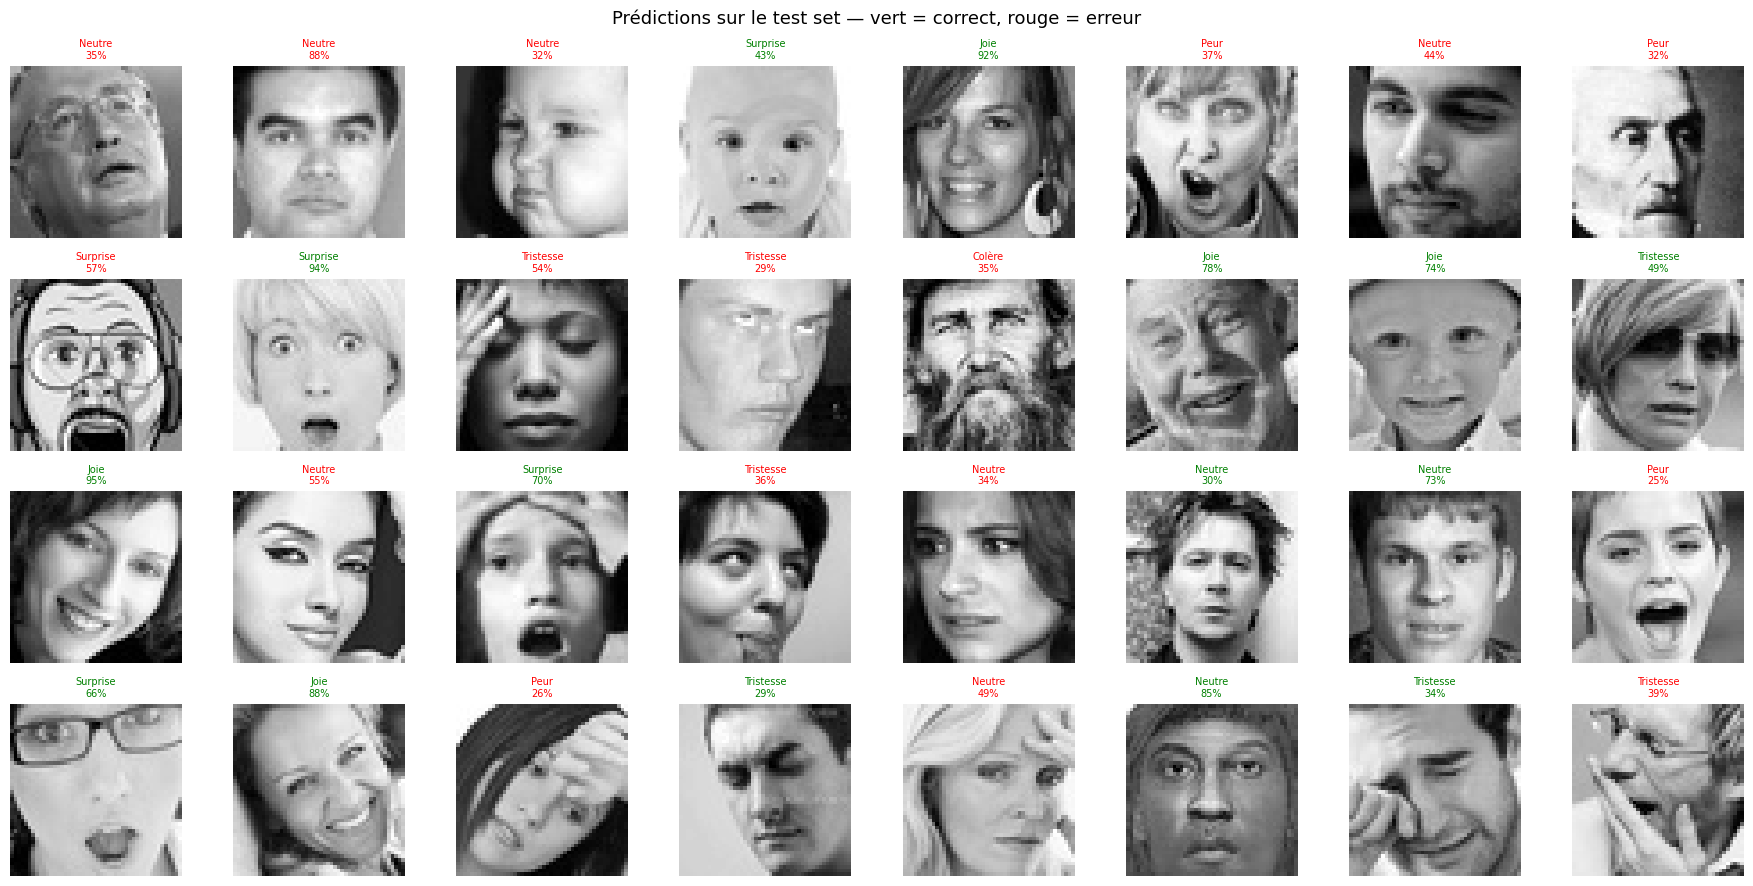

In [29]:
model.eval()
fig, axes = plt.subplots(4, 8, figsize=(18, 9))
fig.suptitle("Prédictions sur le test set — vert = correct, rouge = erreur", fontsize=13)

indices = random.sample(range(len(test_ds)), 32)

for ax, idx in zip(axes.flat, indices):
    img, label = test_ds[idx]
    with torch.no_grad():
        logit = model(img.unsqueeze(0).to(device))
        pred  = logit.argmax(1).item()
        conf  = F.softmax(logit, dim=1).max().item()

    color = "green" if pred == label else "red"
    ax.imshow(img.squeeze().numpy() * 0.5 + 0.5, cmap="gray")
    ax.set_title(f"{EMOTIONS[pred]}\n{conf:.0%}", fontsize=7, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 11. Inférence sur une image uploadée

Uploadez n'importe quelle image contenant un visage pour tester le modèle en direct.


Uploadez une image (jpg/png) :


Saving image2.avif to image2.avif


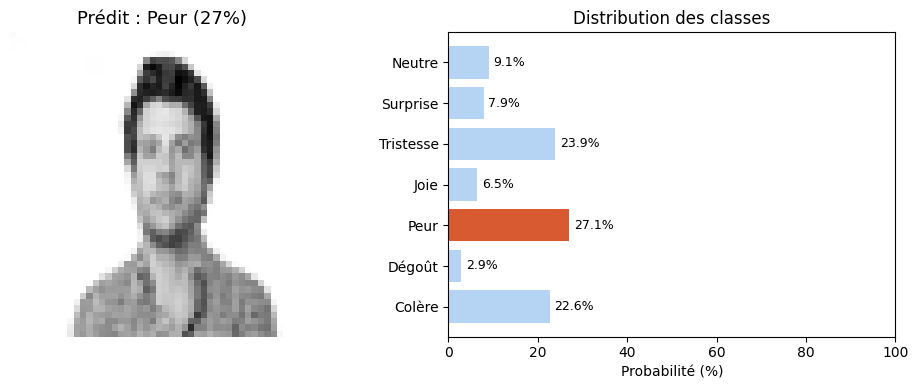

In [33]:
from google.colab import files
import io

print("Uploadez une image (jpg/png) :")
uploaded = files.upload()

for fname, data in uploaded.items():
    img_pil = Image.open(io.BytesIO(data)).convert("L")
    img_pil = img_pil.resize((48, 48))

    tensor = FERDataset.VAL_TF(img_pil).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred = probs.argmax()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.imshow(np.array(img_pil), cmap="gray")
    ax1.set_title(f"Prédit : {EMOTIONS[pred]} ({probs[pred]:.0%})", fontsize=13)
    ax1.axis("off")

    colors = ["#D85A30" if i == pred else "#B5D4F4" for i in range(7)]
    bars   = ax2.barh(EMOTIONS, probs * 100, color=colors)
    ax2.set_xlabel("Probabilité (%)")
    ax2.set_title("Distribution des classes")
    ax2.set_xlim(0, 100)
    for bar, p in zip(bars, probs):
        ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f"{p:.1%}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


## 12. Sauvegarde du modèle sur Google Drive (optionnel)

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import shutil
dest = "/content/drive/MyDrive/FERNet/"
os.makedirs(dest, exist_ok=True)
shutil.copy(CKPT_PATH, dest + "fer_best.pt")
print(f"Modèle sauvegardé dans Google Drive : {dest}fer_best.pt")


## 13. Test en direct avec la caméra

> **Comment ça marche dans Colab :** Colab ne peut pas accéder directement à votre webcam via Python. À la place, on utilise un snippet JavaScript qui capture une photo depuis le navigateur, l'envoie à Python via `eval_js`, et le modèle prédit l'émotion en temps réel.
>
> **Cliquez sur "Autoriser" quand le navigateur demande l'accès à la caméra.**


Ouverture de la caméra… Cliquez sur 📸 Capturer quand vous êtes prêt.
Image capturée : 640×480 px


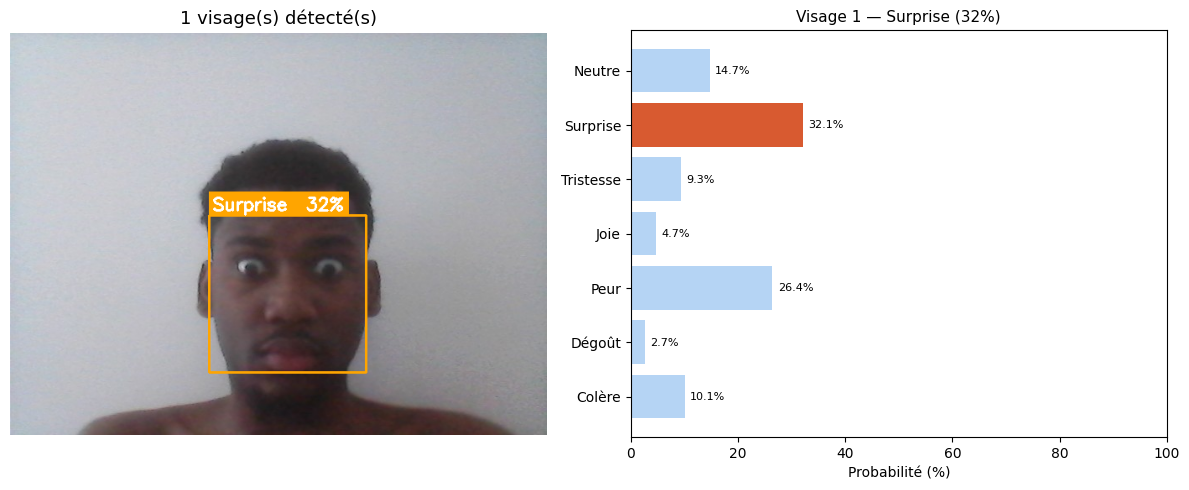

In [35]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode, b64encode
import numpy as np
import cv2
from PIL import Image
import io
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Snippet JS : ouvre la webcam, affiche un aperçu, capture sur clic ───────
JS_CAMERA = """
async function capturePhoto() {
  const div = document.createElement('div');
  div.style.cssText = 'position:relative;display:inline-block;font-family:sans-serif';

  const video = document.createElement('video');
  video.style.cssText = 'width:480px;border-radius:8px;display:block';
  video.autoplay = true;

  const btnCapture = document.createElement('button');
  btnCapture.textContent = '📸  Capturer';
  btnCapture.style.cssText = `
    margin-top:10px;padding:10px 28px;font-size:15px;
    background:#4CAF50;color:#fff;border:none;border-radius:8px;
    cursor:pointer;display:block;width:100%`;

  const canvas = document.createElement('canvas');
  canvas.style.display = 'none';

  div.appendChild(video);
  div.appendChild(btnCapture);
  div.appendChild(canvas);
  document.body.appendChild(div);

  const stream = await navigator.mediaDevices.getUserMedia({video: {width:640, height:480}});
  video.srcObject = stream;

  await new Promise(resolve => btnCapture.onclick = resolve);

  canvas.width  = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);
  stream.getTracks().forEach(t => t.stop());
  div.remove();

  return canvas.toDataURL('image/jpeg', 0.9);
}
capturePhoto();
"""

# ── Détecteur de visage Haar (fourni avec OpenCV, aucun téléchargement) ──────
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

EMOTIONS = ["Colère", "Dégoût", "Peur", "Joie", "Tristesse", "Surprise", "Neutre"]
COLORS_BGR = {
    "Joie":      (50,  205, 50),
    "Surprise":  (0,   165, 255),
    "Neutre":    (200, 200, 200),
    "Colère":    (0,   0,   220),
    "Peur":      (148, 0,   211),
    "Tristesse": (205, 133, 63),
    "Dégoût":    (0,   128, 128),
}

def predict_face(face_gray_48):
    """Prédit l'émotion sur un crop 48×48 en niveaux de gris."""
    tensor = torch.tensor(face_gray_48, dtype=torch.float32)
    tensor = (tensor / 255.0 - 0.5) / 0.5
    tensor = tensor.unsqueeze(0).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    return probs

def process_image(img_bgr):
    """Détecte les visages, prédit les émotions, retourne l'image annotée."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
    )
    results = []
    annotated = img_bgr.copy()

    for (x, y, w, h) in faces:
        # Crop + resize → 48×48
        face_crop = gray[y:y+h, x:x+w]
        face_48   = cv2.resize(face_crop, (48, 48))
        probs     = predict_face(face_48)
        pred      = int(probs.argmax())
        emotion   = EMOTIONS[pred]
        conf      = probs[pred]
        color     = COLORS_BGR[emotion]

        # Dessiner le rectangle et le label
        cv2.rectangle(annotated, (x, y), (x+w, y+h), color, 2)
        label = f"{emotion}  {conf:.0%}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(annotated, (x, y - th - 12), (x + tw + 8, y), color, -1)
        cv2.putText(annotated, label, (x + 4, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        results.append({"bbox": (x, y, w, h), "emotion": emotion,
                        "confidence": conf, "probs": probs})

    return annotated, results

def show_results(img_bgr, results):
    """Affiche l'image annotée + les graphiques de probabilité."""
    n = max(len(results), 1)
    fig, axes = plt.subplots(1, n + 1, figsize=(6 * (n + 1), 5))
    if n == 1: axes = [axes] if len(results) == 0 else axes

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax_main = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
    ax_main.imshow(img_rgb)
    ax_main.set_title(f"{len(results)} visage(s) détecté(s)", fontsize=13)
    ax_main.axis("off")

    for i, res in enumerate(results):
        ax = axes[i + 1]
        probs   = res["probs"]
        emotion = res["emotion"]
        colors  = ["#D85A30" if EMOTIONS[j] == emotion else "#B5D4F4"
                   for j in range(7)]
        bars = ax.barh(EMOTIONS, probs * 100, color=colors)
        ax.set_xlim(0, 100)
        ax.set_xlabel("Probabilité (%)")
        ax.set_title(f"Visage {i+1} — {emotion} ({res['confidence']:.0%})", fontsize=11)
        for bar, p in zip(bars, probs):
            ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    f"{p:.1%}", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    if not results:
        print("⚠️  Aucun visage détecté. Essayez : mieux éclairé, plus centré, plus proche.")

# ── Capture et inférence ─────────────────────────────────────────────────────
print("Ouverture de la caméra… Cliquez sur 📸 Capturer quand vous êtes prêt.")
data_url = eval_js(JS_CAMERA)

# Décoder le base64 → image OpenCV
header, encoded = data_url.split(",", 1)
img_bytes = b64decode(encoded)
img_array = np.frombuffer(img_bytes, dtype=np.uint8)
img_bgr   = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

print(f"Image capturée : {img_bgr.shape[1]}×{img_bgr.shape[0]} px")

# Détecter + prédire + afficher
annotated, results = process_image(img_bgr)
show_results(annotated, results)


### 13b. Mode rafale — plusieurs captures à la suite

Lancez cette cellule pour capturer plusieurs photos d'affilée (utile pour tester différentes expressions).


Mode rafale : 5 captures successives.

── Capture 1/5 ── Cliquez sur 📸 Capturer


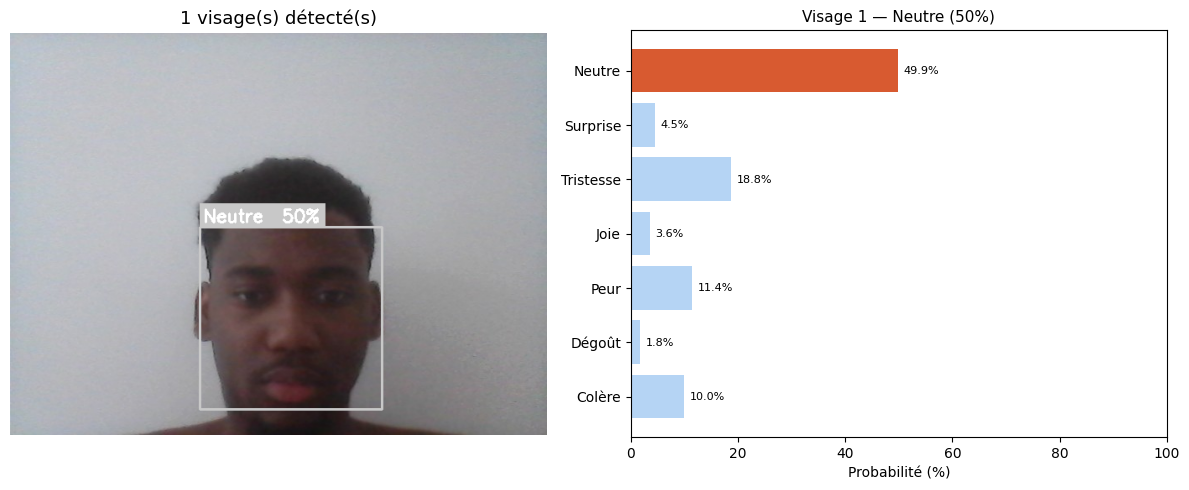


── Capture 2/5 ── Cliquez sur 📸 Capturer


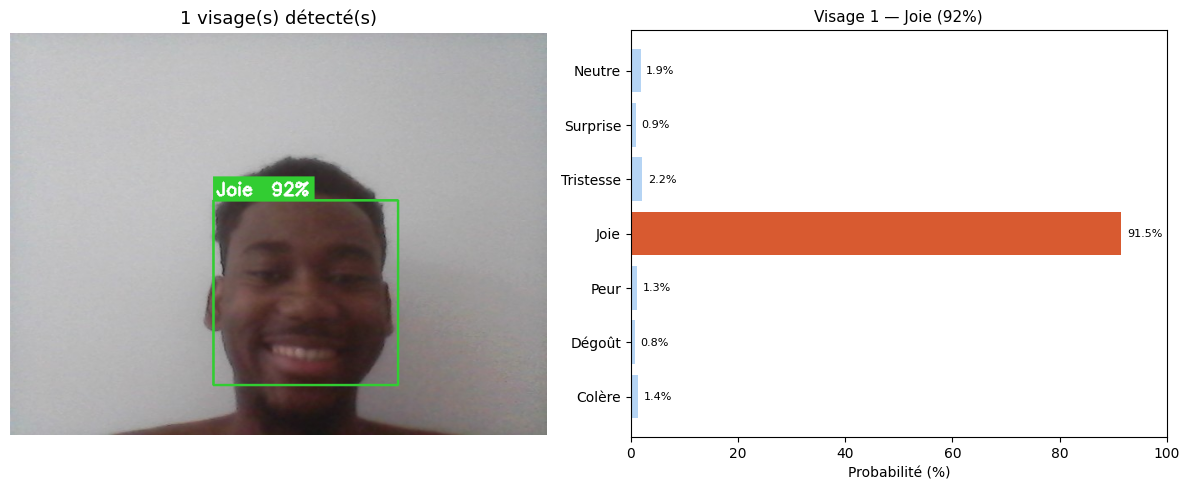


── Capture 3/5 ── Cliquez sur 📸 Capturer


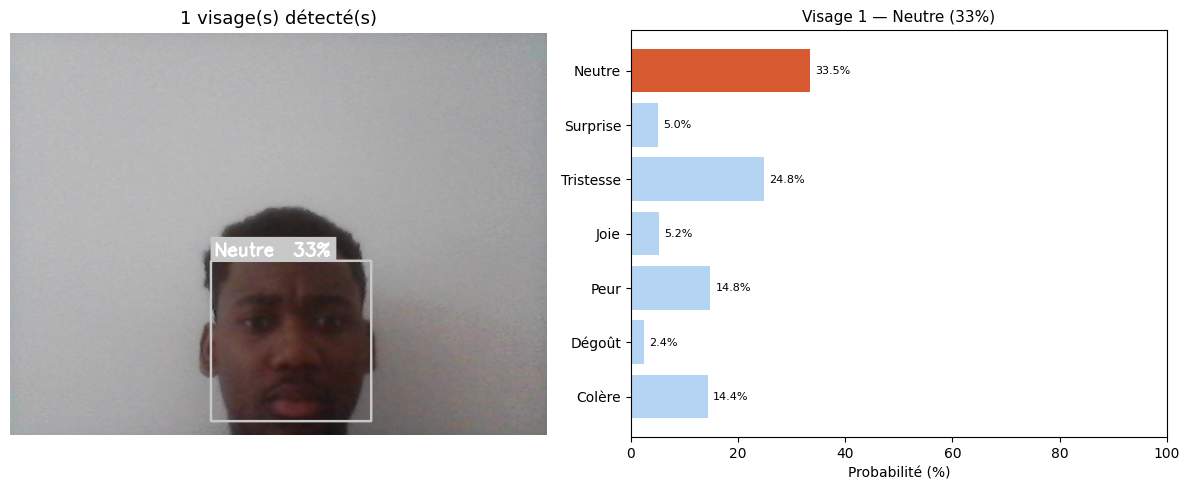


── Capture 4/5 ── Cliquez sur 📸 Capturer


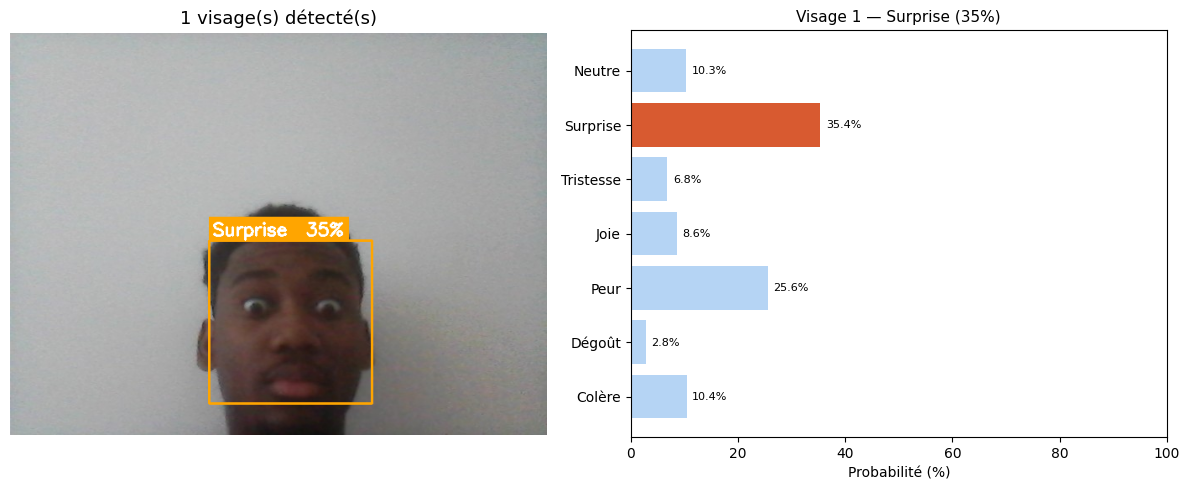


── Capture 5/5 ── Cliquez sur 📸 Capturer


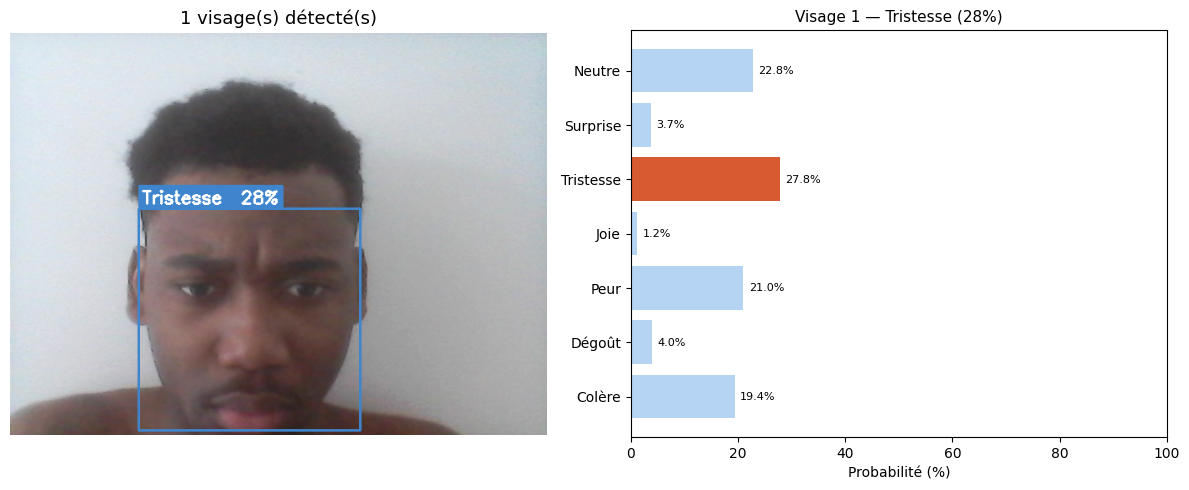

In [36]:
import ipywidgets as widgets
from IPython.display import display, clear_output

N_SHOTS = 5  # nombre de captures
print(f"Mode rafale : {N_SHOTS} captures successives.\n")

for shot in range(1, N_SHOTS + 1):
    print(f"── Capture {shot}/{N_SHOTS} ── Cliquez sur 📸 Capturer")
    data_url = eval_js(JS_CAMERA)
    header, encoded = data_url.split(",", 1)
    img_bytes = b64decode(encoded)
    img_array = np.frombuffer(img_bytes, dtype=np.uint8)
    img_bgr   = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    annotated, results = process_image(img_bgr)
    show_results(annotated, results)
    print()
